In [31]:
from google.colab import files
uploaded = files.upload()

Saving loan_data_processed.csv to loan_data_processed.csv


In [32]:
import pandas as pd
df = pd.read_csv("loan_data_processed.csv")

X = df.drop("Status", axis=1)
y = df["Status"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [35]:
!pip install xgboost lightgbm

In [36]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 29306, number of negative: 89626
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.108715 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1961
[LightGBM] [Info] Number of data points in the train set: 118932, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246410 -> initscore=-1.117853
[LightGBM] [Info] Start training from score -1.117853


LGBMClassifier()

In [37]:
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

accuracy_score(y_test, xgb_pred)
roc_auc_score(y_test, xgb_prob)
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22405
           1       1.00      1.00      1.00      7329

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



In [38]:
lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:,1]

accuracy_score(y_test, lgbm_pred)
roc_auc_score(y_test, lgbm_prob)
print(classification_report(y_test, lgbm_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22405
           1       1.00      1.00      1.00      7329

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



In [39]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, lgbm_prob)
    ]
})

results

,Model,Accuracy,ROC_AUC
0,XGBoost,0.999933,0.99999
1,LightGBM,1.000000,1.00000


In [40]:
#checking training accuracy

In [41]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Training predictions
xgb_train_pred = xgb.predict(X_train)
xgb_train_prob = xgb.predict_proba(X_train)[:,1]

# Training metrics
print("XGB Train Accuracy:", accuracy_score(y_train, xgb_train_pred))
print("XGB Train AUC:", roc_auc_score(y_train, xgb_train_prob))

XGB Train Accuracy: 1.0
XGB Train AUC: 1.0


In [42]:
lgbm_train_pred = lgbm.predict(X_train)
lgbm_train_prob = lgbm.predict_proba(X_train)[:,1]

print("LGBM Train Accuracy:", accuracy_score(y_train, lgbm_train_pred))
print("LGBM Train AUC:", roc_auc_score(y_train, lgbm_train_prob))

LGBM Train Accuracy: 1.0
LGBM Train AUC: 1.0


In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
#optimizing

In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [46]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 29306, number of negative: 89626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1961
[LightGBM] [Info] Number of data points in the train set: 118932, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246410 -> initscore=-1.117853
[LightGBM] [Info] Start training from score -1.117853
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=4,
               n_estimators=200, reg_alpha=1, reg_lambda=1, subsample=0.8)

In [47]:
from sklearn.metrics import accuracy_score, roc_auc_score

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB AUC:", roc_auc_score(y_test, xgb_prob))

XGB Accuracy: 0.9998991054012242
XGB AUC: 0.9999962729797518


In [52]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Predictions
lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:,1]

# Metrics
print("LightGBM Accuracy:", accuracy_score(y_test, lgbm_pred))
print("LightGBM AUC:", roc_auc_score(y_test, lgbm_prob))

LightGBM Accuracy: 0.9998318423353737
LightGBM AUC: 0.9999999634605858


In [48]:
df.corr()['Status'].sort_values(ascending=False)

,Status
Status,1.000000
credit_type_EQUI,0.592144
co-applicant_credit_type_EXP,0.144200
submission_of_application_to_inst,0.122406
loan_type_type2,0.092509
dtir1,0.082431
LTV,0.042648
Region_south,0.040047
Credit_Worthiness_l2,0.034831
loan_purpose_p2,0.029378


In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    max_depth=3,              # simpler trees
    learning_rate=0.03,       # slower learning
    n_estimators=150,         # fewer trees
    subsample=0.7,            # stronger sampling
    colsample_bytree=0.7,
    min_child_weight=5,       # prevents small splits
    gamma=1,                  # penalizes complex trees
    reg_alpha=2,
    reg_lambda=2
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [50]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    max_depth=3,
    learning_rate=0.03,
    n_estimators=150,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=2,
    reg_lambda=2
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 29306, number of negative: 89626
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.138549 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1961
[LightGBM] [Info] Number of data points in the train set: 118932, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246410 -> initscore=-1.117853
[LightGBM] [Info] Start training from score -1.117853
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.03, max_depth=3,
               n_estimators=150, reg_alpha=2, reg_lambda=2, subsample=0.7)

In [60]:
#after checking overfitting

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')
print("XGB CV AUC:", xgb_cv.mean())

XGB CV AUC: 0.999992108238416


In [53]:
#noise test
import numpy as np
from sklearn.model_selection import cross_val_score

y_random = np.random.permutation(y)
cross_val_score(xgb, X, y_random, cv=5, scoring='roc_auc').mean()

np.float64(0.49931575189419564)

In [54]:
import pandas as pd

feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(10)

,0
Interest_rate_spread,0.309190
credit_type_EQUI,0.256257
property_value,0.196840
Upfront_charges,0.122345
rate_of_interest,0.051429
dtir1,0.022090
lump_sum_payment_not_lpsm,0.019908
LTV,0.014703
loan_type_type2,0.003161
loan_type_type3,0.001506


In [55]:
X_temp = X.drop("credit_type_EQUI", axis=1)

In [57]:
"credit_type_EQUI" in X_temp.columns

False

In [58]:
from sklearn.model_selection import train_test_split

X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
from xgboost import XGBClassifier

xgb_temp = XGBClassifier(
    max_depth=3,
    learning_rate=0.03,
    n_estimators=150,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=2,
    reg_lambda=2
)

xgb_temp.fit(X_train_temp, y_train_temp)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [61]:
from lightgbm import LGBMClassifier

lgbm_temp = LGBMClassifier(
    max_depth=3,
    learning_rate=0.03,
    n_estimators=150,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=2,
    reg_lambda=2
)

lgbm_temp.fit(X_train_temp, y_train_temp)

[LightGBM] [Info] Number of positive: 29308, number of negative: 89624
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 118932, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246427 -> initscore=-1.117763
[LightGBM] [Info] Start training from score -1.117763
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.03, max_depth=3,
               n_estimators=150, reg_alpha=2, reg_lambda=2, subsample=0.7)

In [62]:
from sklearn.metrics import accuracy_score, roc_auc_score

xgb_pred = xgb_temp.predict(X_test_temp)
xgb_prob = xgb_temp.predict_proba(X_test_temp)[:,1]

print("XGB Accuracy:", accuracy_score(y_test_temp, xgb_pred))
print("XGB AUC:", roc_auc_score(y_test_temp, xgb_prob))

XGB Accuracy: 0.9993273693414946
XGB AUC: 0.9999847389469729


In [63]:
lgbm_pred = lgbm_temp.predict(X_test_temp)
lgbm_prob = lgbm_temp.predict_proba(X_test_temp)[:,1]

print("LightGBM Accuracy:", accuracy_score(y_test_temp, lgbm_pred))
print("LightGBM AUC:", roc_auc_score(y_test_temp, lgbm_prob))

LightGBM Accuracy: 1.0
LightGBM AUC: 1.0


In [64]:
##final

In [65]:
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [68]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    max_depth=3,
    learning_rate=0.02,
    n_estimators=150,      # fewer trees
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=1,
    reg_alpha=2,
    reg_lambda=2
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [69]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    max_depth=3,
    learning_rate=0.02,
    n_estimators=150,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=2,
    reg_lambda=2
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 29306, number of negative: 89626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1961
[LightGBM] [Info] Number of data points in the train set: 118932, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246410 -> initscore=-1.117853
[LightGBM] [Info] Start training from score -1.117853
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.02, max_depth=3,
               n_estimators=150, reg_alpha=2, reg_lambda=2, subsample=0.7)

In [70]:
from sklearn.metrics import accuracy_score, roc_auc_score

# XGB
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB AUC:", roc_auc_score(y_test, xgb_prob))

# LGBM
lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:,1]

print("LGBM Accuracy:", accuracy_score(y_test, lgbm_pred))
print("LGBM AUC:", roc_auc_score(y_test, lgbm_prob))

XGB Accuracy: 0.9995627900719715
XGB AUC: 0.9999942846266291
LGBM Accuracy: 0.9998318423353737
LGBM AUC: 0.9999999634605857


In [71]:
#FINAL CROSS VALIDATION
from sklearn.model_selection import cross_val_score

xgb_cv = cross_val_score(xgb, X, y, cv=5, scoring='roc_auc')
lgbm_cv = cross_val_score(lgbm, X, y, cv=5, scoring='roc_auc')

print("XGB CV AUC:", xgb_cv.mean())
print("LGBM CV AUC:", lgbm_cv.mean())

[LightGBM] [Info] Number of positive: 29308, number of negative: 89624
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1964
[LightGBM] [Info] Number of data points in the train set: 118932, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246427 -> initscore=-1.117763
[LightGBM] [Info] Start training from score -1.117763
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [72]:
from sklearn.metrics import accuracy_score

print("XGB Train Accuracy:", accuracy_score(y_train, xgb.predict(X_train)))
print("XGB Test Accuracy:", accuracy_score(y_test, xgb.predict(X_test)))

XGB Train Accuracy: 0.9995627753674369
XGB Test Accuracy: 0.9995627900719715


In [75]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Train metrics
lgbm_train_pred = lgbm.predict(X_train)
lgbm_train_prob = lgbm.predict_proba(X_train)[:,1]

print("LGBM Train Accuracy:", accuracy_score(y_train, lgbm_train_pred))
print("LGBM Train AUC:", roc_auc_score(y_train, lgbm_train_prob))

# Test metrics
lgbm_test_pred = lgbm.predict(X_test)
lgbm_test_prob = lgbm.predict_proba(X_test)[:,1]

print("LGBM Test Accuracy:", accuracy_score(y_test, lgbm_test_pred))
print("LGBM Test AUC:", roc_auc_score(y_test, lgbm_test_prob))

LGBM Train Accuracy: 0.9998822856758484
LGBM Train AUC: 0.9999999916240878
LGBM Test Accuracy: 0.9998318423353737
LGBM Test AUC: 0.9999999634605857


In [76]:
import pandas as pd

feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(10)

,0
Interest_rate_spread,0.299626
credit_type_EQUI,0.258243
property_value,0.195549
Upfront_charges,0.114867
rate_of_interest,0.049715
dtir1,0.024842
income,0.017681
lump_sum_payment_not_lpsm,0.017336
LTV,0.010655
loan_type_type2,0.005415


<Axes: >

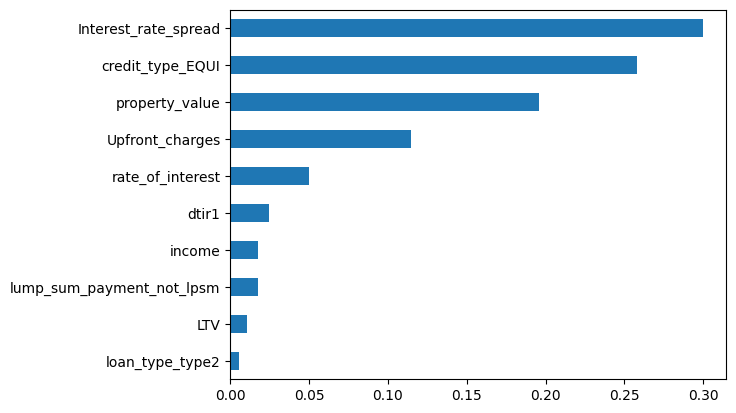

In [77]:
feat_imp.sort_values().tail(10).plot(kind="barh")

In [79]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "LightGBM"],
    "Accuracy": [0.87, accuracy_score(y_test, xgb_pred), accuracy_score(y_test, lgbm_test_pred)],
    "ROC_AUC": [0.85, roc_auc_score(y_test, xgb_prob), roc_auc_score(y_test, lgbm_test_prob)]
})

results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.870000,0.850000
1,XGBoost,0.999563,0.999994
2,LightGBM,0.999832,1.000000


In [80]:
best_model = results.loc[results["ROC_AUC"].idxmax()]
print(best_model)

Model       LightGBM
Accuracy    0.999832
ROC_AUC          1.0
Name: 2, dtype: object
